# Classification Metrics

Learning objectives:

1. Distinguish between classification metrics on the basis of $FP$ and $FN$
2. Given a confusion matrix; tell the performance of a classifier
3. Given a PR-curve or ROC-curve; be able to tell which classifier is better
4. Given a set of classifiers; evaluate and select the best one

## Why are metrics important?

> If you can measure it you can improve it.

- Metrics help capture a business goal into a quantitative target
- Helps organize ML team effort towards that target
- Useful to quantify the “gap” between:
  - How far from a guessing model?
  - How far from a perfect model?
  - Measure progress over time.
- Make trade-offs between metrics to optimize value

This notebook aims at giving an overview of the classification metrics that can be used to evaluate the predictive model generalization performance.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_openml

In [2]:
diabetes = fetch_openml(data_id=37, as_frame=True, parser="pandas")
X, y = diabetes.data, diabetes.target

We can have a first look at the at the dataset loaded.



In [3]:
X

,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


 Let's start by checking the classes present in the target vector `target`.

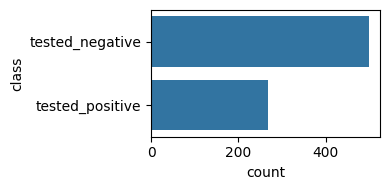

In [4]:
plt.figure(figsize=(4, 2))
sns.countplot(y=y)
plt.tight_layout()

In [5]:
neg_label = 'tested_negative'
pos_label = 'tested_positive'
# The target contains 'tested_positive' and 'tested_negative'.
# We map 'tested_positive' to 1 (the class where False Negatives occur).
y = (y == pos_label).astype(int)

- `stratify=y` ensures that the class distribution in the train set is the same as in the target vector

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    random_state=42,
    test_size=0.4
)

- We will use a logistic regression classifier as a base model.
- We will train the model on the train set, and later use the test set to compute the different classification metrics.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])

classifier.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

## Accuracy as a baseline

 This measure is called the accuracy. Here, our classifier is 78% accurate at classifying if a subject will give blood. `scikit-learn` provides a function that computes this metric in the module `sklearn.metrics`.

In [8]:
from sklearn.metrics import accuracy_score

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")


Accuracy: 0.737


 `LogisticRegression` also has a method named `score` (part of the standard scikit-learn API), which computes the accuracy score.

In [9]:
classifier.score(X_test, y_test)

0.737012987012987

### How good is `74%`?

**Accuracy** is the fraction of correct predictions.

$$
\text{Accuracy} = \frac{TP + TN}{\text{Count}}
$$

When the positive class is rare, a model that *always* predicts the majority class can get high accuracy without learning to spot the minority at all.

Let's compare against a `DummyClassifier` as a baseline:

In [10]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")
dummy_classifier.fit(X_train, y_train)
dummy_classifier.score(X_test, y_test)

0.6525974025974026

In [11]:
difference = classifier.score(X_test, y_test) - dummy_classifier.score(X_test, y_test)
print(f"difference: {difference:.3f}")

difference: 0.084


- Our model is `+8.4%` better than a Dummy Classifier; judged by the metric: **Accuracy**
- Is this value good enough? No.
- Is accuracy a good metric for imbalanced data? No.

## Point Metrics

### Confusion Matrix

The comparison that we did above and the accuracy that we calculated did not take into account the type of error our classifier was making. We may be interested in finer granularity - **to know independently what the error is for each of the two following cases**:

- **False Positives** ($FP$): we predicted that a person is diabetic but they did not test positive;
- **False Negatives** ($FN$): we predicted that a person isn't diabetic but they actually tested positive.

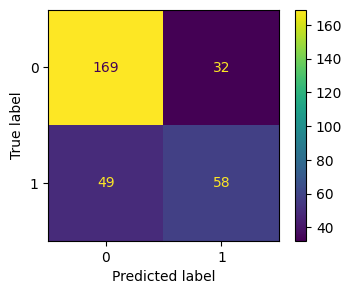

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(4, 3))
_ = ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, ax=ax)

- The in-diagonal numbers are related to predictions that were correct ($T$)
  - **True Positives** ($TP$)
  - **True Negatives** ($TP$)
- The off-diagonal numbers are related to misclassifications ($F$); mentioned earlier: $FP$ and $FN$.

We can breakdown the numbers in scikit-learn using the `confusion_matrix` function as follows:

In [13]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()

print(f"True negatives: {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives: {tp}")

True negatives: 169
False positives: 32
False negatives: 49
True positives: 58


Let's look at the confusion matrix of two dummy classifiers; one always predicts 1 and the other always predicts 0:

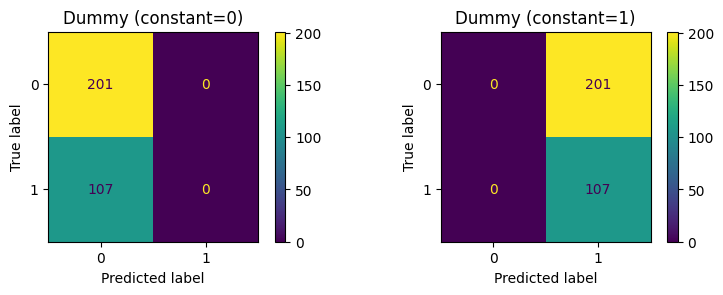

In [14]:
# Instantiate both dummy classifiers
dummy_0 = DummyClassifier(strategy="constant", constant=0)
dummy_1 = DummyClassifier(strategy="constant", constant=1)

# Train both dummy classifiers
dummy_0.fit(X_train, y_train)
dummy_1.fit(X_train, y_train)

# Plot both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

ConfusionMatrixDisplay.from_estimator(dummy_0, X_test, y_test, ax=axes[0])
axes[0].set_title("Dummy (constant=0)")

ConfusionMatrixDisplay.from_estimator(dummy_1, X_test, y_test, ax=axes[1])
axes[1].set_title("Dummy (constant=1)")

plt.tight_layout()

## Precision and Recall

**Precision** is the accuracy of the positive predictions.  Proportional to lower $FP$:

$$ \text{Precision} = \frac{TP}{TP + FP} $$


**Recall** is the coverage of actual positive sample. Proportional to lower $FN$:

$$ \text{Recall} = \frac{TP}{TP + FN} $$

In [15]:
from sklearn.metrics import precision_score, recall_score

# Collect results for all three models
model_results = [
    ("Logistic Regression", y_pred),
    ("Dummy (constant=0)", dummy_0.predict(X_test)),
    ("Dummy (constant=1)", dummy_1.predict(X_test)),
]

rows = []
for name, preds in model_results:
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    rows.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall
    })

df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.set_index("Model")
display(df_metrics)

,Precision,Recall
Model,,
Logistic Regression,0.644444,0.542056
Dummy (constant=0),0.000000,0.000000
Dummy (constant=1),0.347403,1.000000


### Point Metrics Summary

The following metrics are commonly used to assess the performance of classification models:

| Metric | Formula | Interpretation |
| :--- | :--- | :--- |
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Overall performance of model |
| **Precision** | $\frac{TP}{TP + FP}$ | How accurate the positive predictions are |
| **Recall or Sensitivity** | $\frac{TP}{TP + FN}$ | Coverage of actual positive sample |
| **Specificity** | $\frac{TN}{TN + FP}$ | Coverage of actual negative sample |
| **F1 score** | $\frac{2TP}{2TP + FP + FN}$ | Hybrid metric useful for unbalanced classes |

You find them in the `sklearn.metrics` module:

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

Follow up questions:

- What component in a classifier plays role in this precision-recall trade-off?
- Can we optimize either for precision, recall, or both?

## Thresholding after: Probability and Distance

[Demo: Classifier Threshold effect on point and summary metrics](./widget_threshold.qmd).

When a binary classifier is trained, it doesn't actually "pick a side" immediately. Instead, it generates a continuous numerical value for each input. The `predict` method is simply a final, automated step that applies a hard cutoff to that number to give you a categorical answer (e.g., "Yes" or "No").

A classifiers' [predict](https://scikit-learn.org/stable/glossary.html#term-predict) method outputs class label predictions corresponding to a thresholding of either:

1. the [predict_proba](https://scikit-learn.org/stable/glossary.html#term-predict_proba) output.
   - Positive if **Probability** $\gt 0.5$ else Negative
2. the [decision_function](https://scikit-learn.org/stable/glossary.html#term-decision_function)
   - Positive if **Distance** $\gt 0.0$ else Negative

This table categorizes scikit-learn classifiers by the internal numeric value they threshold to determine the final class label in the predict method:

| **Category**                  | **Key Estimators**                                                             | **Primary Threshold Metric** |
| ----------------------------- | ------------------------------------------------------------------------------ | ---------------------------- |
| **Linear / Geometric**        | `LinearSVC`, `SVC`, `SGDClassifier`, `Perceptron`                              | **`decision_function`**      |
| **Probabilistic / Frequency** | `RandomForestClassifier`, `GradientBoostingClassifier`, `ExtraTreesClassifier` | **`predict_proba`**          |
| **Generative**                | `GaussianNB`, `MultinomialNB`, `BernoulliNB`                                   | **`predict_proba`**          |
| **Instance-based**            | `KNeighborsClassifier`                                                         | **`predict_proba`**          |
| **Neural Networks**           | `MLPClassifier`                                                                | **`predict_proba`**          |
| **The Hybrid**                | `LogisticRegression`                                                           | **Both**                     |

### A. `predict_proba()`

Now let's find out the probability on the first 5 samples of the test set:

In [42]:
import pandas as pd

pd.DataFrame(
    classifier.predict_proba(X_test[0:5]),
    columns=classifier.classes_
).round(2)

,0,1
0,0.95,0.05
1,0.85,0.15
2,0.54,0.46
3,0.88,0.12
4,0.88,0.12


Each cell is a value between **0.0 and 1.0** representing the **posterior probability**—the likelihood that a given input belongs to the positive class (and the negative class).

Notice how each row sums up to 1.

### B. `decision_function()`

Notice that logistic regression also has an underlying `decision_function`; giving numerical outcomes:

In [43]:
classifier.decision_function(X_test[:5])

array([-2.9286347 , -1.77166281, -0.15607328, -2.02963215, -1.98697811])

This calculates a **signed distance** from a decision boundary:

- A score of **0.0** means the data point lies exactly on the boundary.
- A **positive score** means the point is on one side (Class A).
- A **negative score** means it is on the other (Class B).
- The magnitude (e.g., +5.2 vs +0.1) indicates the model's "confidence" or distance from the point of uncertainty.

### C. The gate function: `predict()`

The `predict` method acts on the decision threshold. By default, scikit-learn uses the following logic:

|**Method**|**Logic**|**Result**|
|---|---|---|
|**Decision Function**|If Score $> 0.0$|Predict Class 1|
|**Predict Proba**|If Probability $> 0.5$|Predict Class 1|

In [44]:
classifier.predict(X_test[:3]).tolist()

[0, 0, 0]

## Summary Metrics: Curves

The default decision threshold (0.5) might not be the best threshold that leads to optimal generalization performance of our classifier. In this case, one can vary the decision threshold, and therefore the underlying prediction, and compute the same statistics presented earlier.

We will look at two metrics which are available in sklearn:

In [45]:
from sklearn.metrics import precision_recall_curve
import pandas as pd

# Compute precision, recall, thresholds for the PR-curve
precision, recall, thresholds = precision_recall_curve(y_test, classifier.predict_proba(X_test)[:, 1])

# The thresholds array is shorter by one compared to precision and recall
# Add leading element to precision and recall to align with thresholds for display
pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[1:],  # skip the first precision (for threshold below min score)
    "recall": recall[1:]         # skip the first recall (for threshold below min score)
})

pr_df

,threshold,precision,recall
0,0.002168,0.348534,1.000000
1,0.007067,0.349673,1.000000
2,0.010212,0.350820,1.000000
3,0.015589,0.351974,1.000000
4,0.015697,0.353135,1.000000
...,...,...,...
303,0.938332,1.000000,0.037383
304,0.952284,1.000000,0.028037
305,0.953693,1.000000,0.018692
306,0.965685,1.000000,0.009346


Usually, the two metrics recall and precision are computed and plotted on a graph. Each metric plotted on a graph axis and each point on the graph corresponds to a specific decision threshold.

Let's plot the **Precision-recall curve (PR-curve)**:

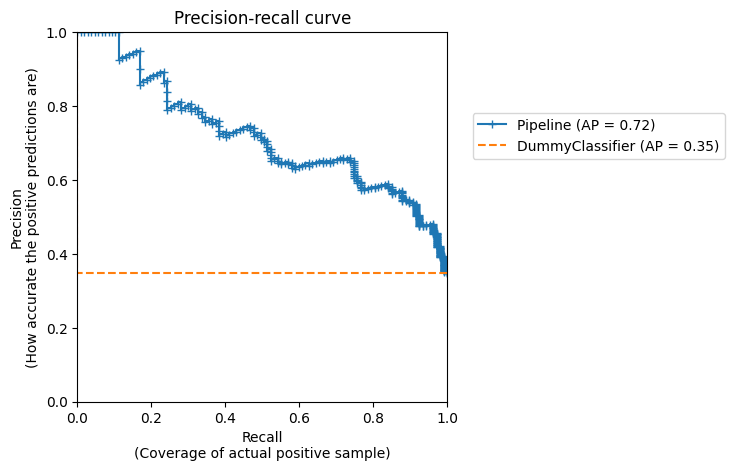

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_estimator(
    estimator=classifier,
    X=X_test,
    y=y_test,
    marker="+",
)
disp = PrecisionRecallDisplay.from_estimator(
    dummy_classifier,
    X_test,
    y_test,
    color="tab:orange",
    linestyle="--",
    ax=disp.ax_,
)
plt.xlabel("Recall\n(Coverage of actual positive sample)")
plt.ylabel("Precision\n(How accurate the positive predictions are)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = disp.ax_.set_title("Precision-recall curve")


- Each blue cross represents a **decision threshold**; varying it maps the trade-off between precision and recall.
  - In other words, each blue cross has its own confusion matrix; for some related decision threshold (not-visible in this plot).
- **Ideal Performance:** A perfect classifier maintains a precision of 1.0 across all recall levels, resulting in an **Average Precision (AP)**—the area under the curve—of 1.0.
- **Baseline Performance:** A baseline `DummyClassifier` yields an AP equal to the **prevalence** (the ratio of positive samples to the total population).

::: {.callout-tip}

 Scikit-learn will return a display containing all plotting element. Notably, displays will expose a matplotlib axis, named `ax_`, that can be used to add new element on the axis. You can refer to the documentation to have more information regarding the [visualizations in scikit-learn](https://scikit-learn.org/stable/visualizations.html#visualizations)

:::


In [47]:
y_test.value_counts()

class
0    201
1    107
Name: count, dtype: int64

In [48]:
print("Prevalnce:", (y_test.value_counts().iloc[1] / y_test.value_counts().sum()).round(2))

Prevalnce: 0.35


The **Receiver Operating Characteristic (ROC) curve** plots the trade-off between **Sensitivity** and **Specificity** as the decision threshold varies:

In [49]:
from sklearn.metrics import roc_curve
import pandas as pd

# Compute false positive rate, true positive rate, thresholds for ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, classifier.predict_proba(X_test)[:, 1])

# Build DataFrame for ROC curve values
roc_df = pd.DataFrame({
    "threshold": roc_thresholds,
    "fpr": fpr,   # false positive rate
    "tpr": tpr    # true positive rate
})

roc_df

,threshold,fpr,tpr
0,inf,0.000000,0.000000
1,0.978720,0.000000,0.009346
2,0.900505,0.000000,0.112150
3,0.892745,0.004975,0.112150
4,0.851536,0.004975,0.168224
...,...,...,...
93,0.074895,0.815920,0.981308
94,0.073461,0.815920,0.990654
95,0.018840,0.975124,0.990654
96,0.017893,0.975124,1.000000


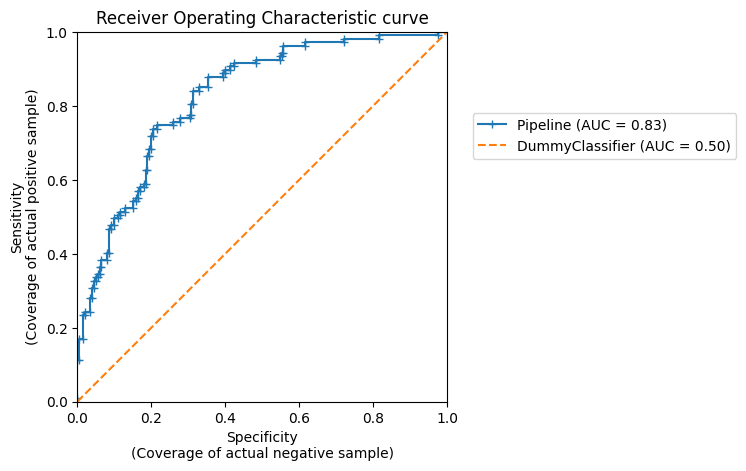

In [ ]:
from sklearn.metrics import RocCurveDisplay

disp = RocCurveDisplay.from_estimator(
    classifier, X_test, y_test,
    curve_kwargs={"marker": "+"}
)
disp = RocCurveDisplay.from_estimator(
    dummy_classifier,
    X_test,
    y_test,
    curve_kwargs={
        "color": "tab:orange",
        "linestyle": "--",
    },
    ax=disp.ax_,
)
plt.xlabel("Specificity\n(Coverage of actual negative sample)")
plt.ylabel("Sensitivity\n(Coverage of actual positive sample)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = disp.ax_.set_title("Receiver Operating Characteristic curve")

This curve was built using the same principle as the precision-recall curve: we vary the probability threshold for determining "hard" prediction and compute the metrics.

As with the precision-recall curve, we can compute the area under the ROC (ROC-AUC) to characterize the generalization performance of our classifier. However, it is important to observe that the lower bound of the ROC-AUC is 0.5. Indeed, we show the generalization performance of a dummy classifier (the orange dashed line) to show that even the worst generalization performance obtained will be above this line. Instead of using a dummy classifier, you can use the parameter `plot_chance_level` available in the ROC and PR displays.

## Comparing Classifiers

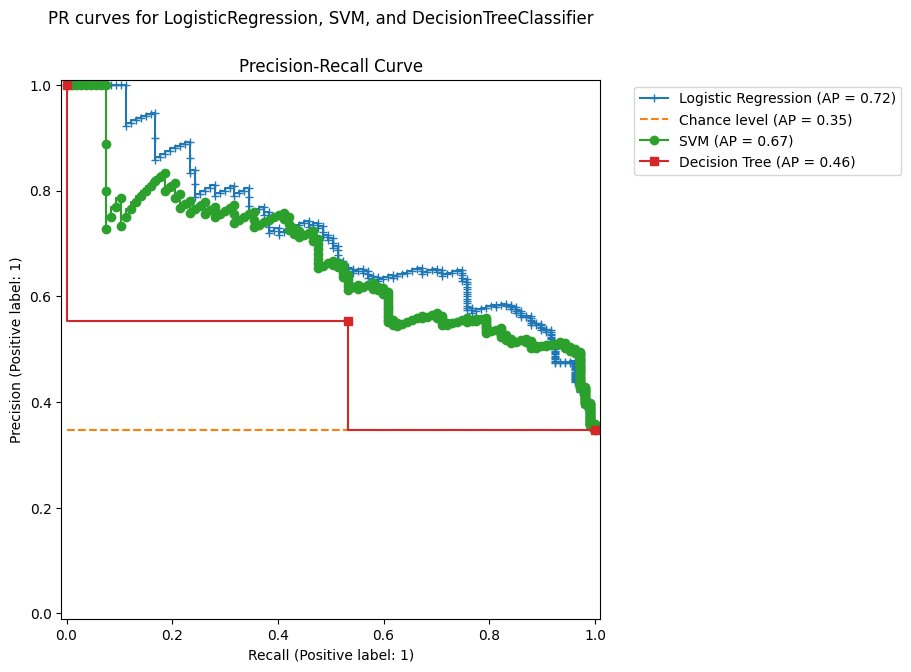

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import PrecisionRecallDisplay

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("SVM", SVC(probability=True, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42))
]

fig, ax = plt.subplots(figsize=(8, 7))

colors = ["tab:blue", "tab:green", "tab:red"]
markers = ["+", "o", "s"]  # use different markers if desired, or leave single style

for i, (model_name, model) in enumerate(models):
    model.fit(X_train, y_train)
    pr_disp = PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=model_name,
        plot_chance_level=(i == 0),  # plot chance level only for first to avoid duplication
        chance_level_kw={"color": "tab:orange", "linestyle": "--"},
    )
    # Customize color and marker
    pr_disp.line_.set_color(colors[i])
    pr_disp.line_.set_marker(markers[i])

ax.set_title("Precision-Recall Curve")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
_ = fig.suptitle("PR curves for LogisticRegression, SVM, and DecisionTreeClassifier")

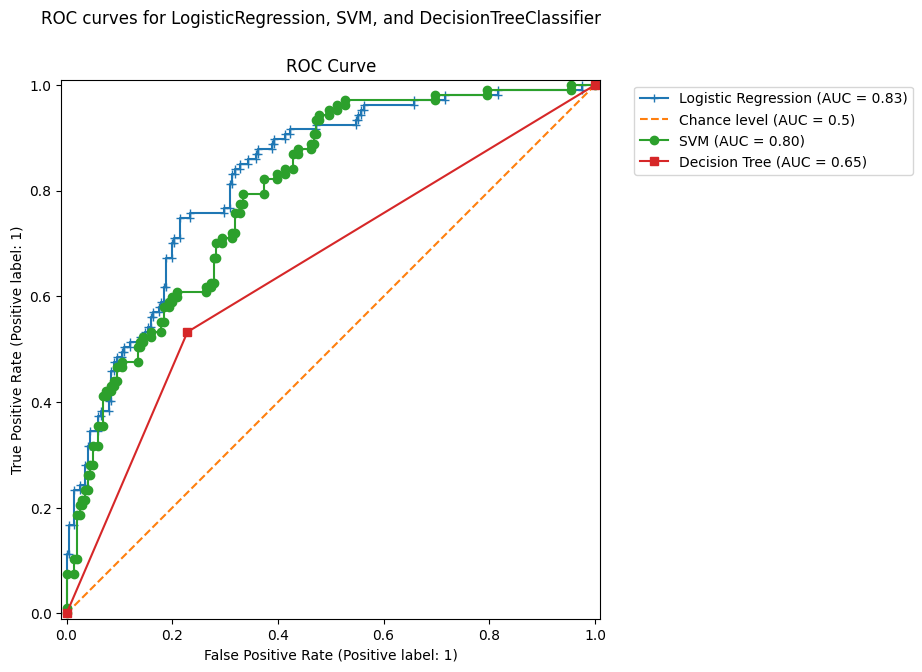

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import RocCurveDisplay

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("SVM", SVC(probability=True, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42))
]

fig, ax = plt.subplots(figsize=(8, 7))

colors = ["tab:blue", "tab:green", "tab:red"]
markers = ["+", "o", "s"]  # use different markers if desired

for i, (model_name, model) in enumerate(models):
    model.fit(X_train, y_train)
    roc_disp = RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=model_name,
        plot_chance_level=(i == 0),  # plot chance level only for first to avoid duplication
        chance_level_kw={"color": "tab:orange", "linestyle": "--"},
    )
    roc_disp.line_.set_color(colors[i])
    roc_disp.line_.set_marker(markers[i])

ax.set_title("ROC Curve")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
_ = fig.suptitle("ROC curves for LogisticRegression, SVM, and DecisionTreeClassifier")